## Importing Libraries and Loading Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv(r"C:\Users\oluwa\OneDrive\Documents\Data Science_ML\Stroke Risk Prediction\Stroke Risk\healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
df = df.rename(columns={'Residence_type': 'residence_type'})

# Data Validation & Cleaning

The dataset contains 5,110 observations and 12 variables.
  
The **BMI** variable contains missing values  (~4% of observations). A BMI missingness indicated has been created to preserve potential signal associated with missingness before imputing.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 634.7 KB


In [5]:
df['id'].nunique()

5110

**Stroke** events are relatively rare in the dataset, with only 4.9% of individuals having experienced a stroke. This pronounced class imbalance in the target variable will influence the choice of evaluation metrics, and class imbalance handling strategies will be considered during the modelling phase.

In [6]:
df['stroke'].value_counts(normalize = True)

stroke
0    0.951272
1    0.048728
Name: proportion, dtype: float64

In [7]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


**Gender** contains a single observation in the “Other” category. Due to its negligible frequency this category will be removed from further analysis.

**Smoking status** includes an “Unknown” category representing approximately 30% of observations. Given its substantial prevalence and potential association with healthcare access or reporting bias, this category will be retained as a distinct group rather than treated as missing.

**Work Type:** "Children" and "Never worked" categories will be merged into a single "Not working" 

In [8]:
for col in df.select_dtypes('object').columns:
    display(df[col].value_counts())

C:\Users\oluwa\AppData\Local\Temp\ipykernel_2868\1046086295.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes('object').columns:


gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

ever_married
Yes    3353
No     1757
Name: count, dtype: int64

work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

In [9]:
df.drop(df[df['gender'] == 'Other'].index, inplace = True)

In [10]:
# Merging "children" and "Never_worked" categories to "Not working"
df['work_type'] = df['work_type'].replace({'children':'Not working', 'Never_worked':'Not working', 'Govt_job':'Government Job'})

In [11]:
df['smoking_status'] = df['smoking_status'].str.capitalize()
df['smoking_status'].value_counts()

smoking_status
Never smoked       1892
Unknown            1544
Formerly smoked     884
Smokes              789
Name: count, dtype: int64

In [12]:
# Converting "smoking_order" into a category column
smoking_order = ['Never smoked', 'Formerly smoked', 'Smokes', 'Unknown']

df['smoking_status'] = pd.Categorical(df['smoking_status'], categories = smoking_order, ordered = True)

# Splitting into Training and Test datasets

In [13]:
train_df, test_df = train_test_split(df, test_size= 0.2, stratify= df['stroke'], random_state=42)

### Handling Missing BMI Values
BMI was imputed using the median value for each (age_group and gender) combination. If a particular (age_group, gender) combination did not exist in the training set, the overall median BMI was used as a fallback.

In [14]:
train_df.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
residence_type         0
avg_glucose_level      0
bmi                  163
smoking_status         0
stroke                 0
dtype: int64

In [15]:
# Proportion of missing BMI values
train_df.groupby(df['bmi'].isna())['stroke'].mean()


bmi
False    0.041284
True     0.226994
Name: stroke, dtype: float64

A BMI missingness indicator (bmi_missing) was created to explicitly capture whether an individual’s BMI value was missing in the original dataset. This approach allows the model to learn any potential predictive signal carried by missingness itself (e.g., differences in healthcare access, clinical recording practices, or underlying health status). The indicator was retained as a separate clinical feature alongside the imputed BMI values.

In [16]:
# Creating a bmi_missing column
train_df['bmi_missing'] = train_df['bmi'].isna().astype(int)
test_df['bmi_missing']  = test_df['bmi'].isna().astype(int)

In [17]:
def create_age_groups(df):
    df = df.copy()
    df['age_group'] = pd.cut(df['age'], bins =[0, 30, 45, 60, 75, 100], 
                              labels=['0-30', '31-45', '46-60', '61-75', '76+'])
    return df

train_df = create_age_groups(train_df)
test_df = create_age_groups(test_df)

In [18]:
# imputing median BMI values
median_bmi = train_df.groupby(['age_group', 'gender'])['bmi'].median()

def impute_bmi(row):
    if pd.isna(row['bmi']):
        return median_bmi.get((row['age_group'], row['gender']), train_df['bmi'].median())
    return row['bmi']

train_df['bmi'] = train_df.apply(impute_bmi, axis=1)
test_df['bmi']  = test_df.apply(impute_bmi, axis=1)

# Exploratory Data Analysis

In [19]:
sns.set_style('white')

### Prevalence of stroke among the population

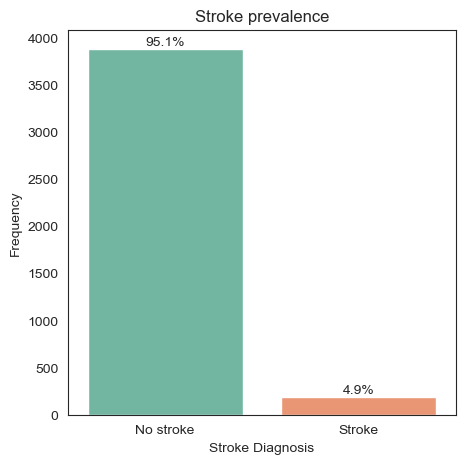

In [20]:
df_stroke = (
    train_df['stroke']
    .value_counts()
    .rename_axis('stroke')
    .reset_index(name='count')
)

total = df_stroke['count'].sum()

plt.figure(figsize=(5, 5))
ax = sns.barplot(
    data=df_stroke,
    x='stroke',
    y='count',
    palette='Set2', hue = 'stroke',
    legend = False
)

for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(
        f'{percentage:.1f}%',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.ylabel('Frequency')
plt.xlabel('Stroke Diagnosis')
plt.xticks(ticks = [0,1], labels = ['No stroke', 'Stroke'])
plt.title('Stroke prevalence')
plt.show()


### Distribution of numerical features
Both average glucose level and BMI exhibit right-skewed distributions with the presence of extreme values, as evident from the box plots. These suggest potential influence of outliers, which will be appropriately addressed during the preprocessing stage.

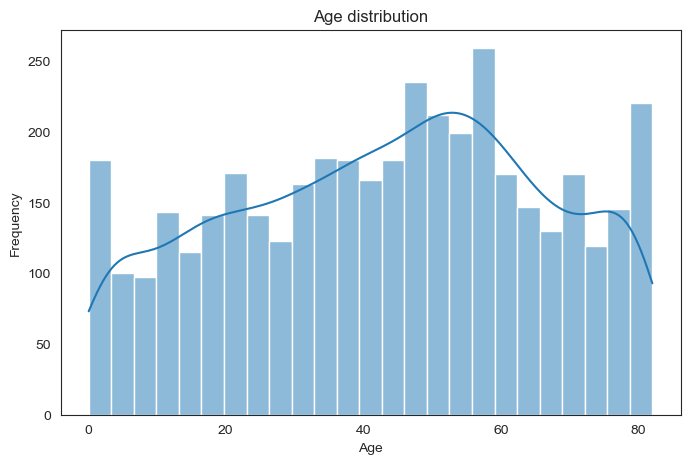

In [21]:
# Age distribution
plt.figure(figsize=(8,5))

sns.histplot(data = train_df, x = 'age', bins = 25, kde = True)

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age distribution')
plt.show()

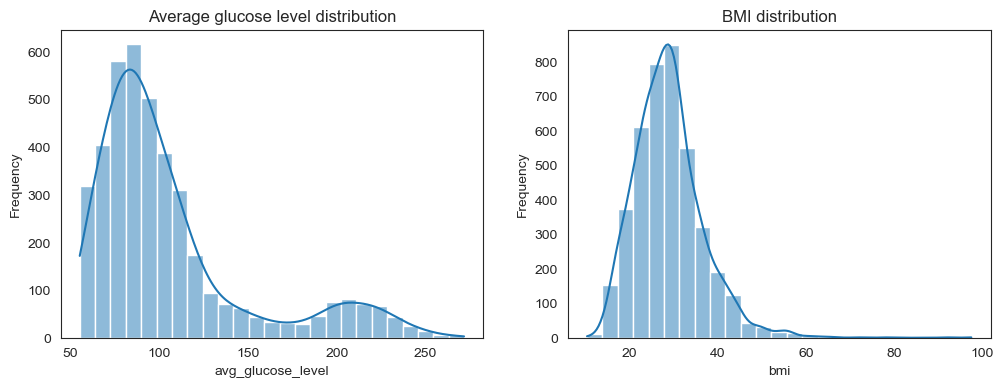

In [22]:
cols = ['avg_glucose_level', 'bmi']
title = {'avg_glucose_level':'Average glucose level',
         'bmi':'BMI'}

fig, axes = plt.subplots(1, 2, figsize = (12,4))

for ax, col in zip(axes, cols):
    sns.histplot(data = train_df, x = col, bins = 25, kde = True, ax = ax)

    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{title[col]} distribution')

plt.show()

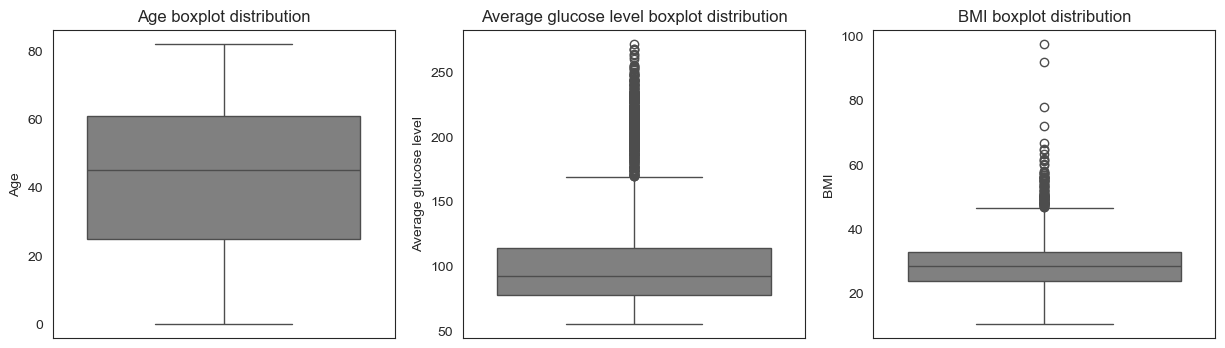

In [23]:
cols = ['age','avg_glucose_level', 'bmi']
title = {'age':'Age',
         'avg_glucose_level':'Average glucose level',
         'bmi':'BMI'}

fig, axes = plt.subplots(1, 3, figsize = (15,4))

for ax, col in zip(axes, cols):
    sns.boxplot(data = train_df, y = col, color = 'grey', ax = ax)

    ax.set_ylabel(title[col])
    ax.set_title(f'{title[col]} boxplot distribution')

plt.show()

### Distribution of categoricl features

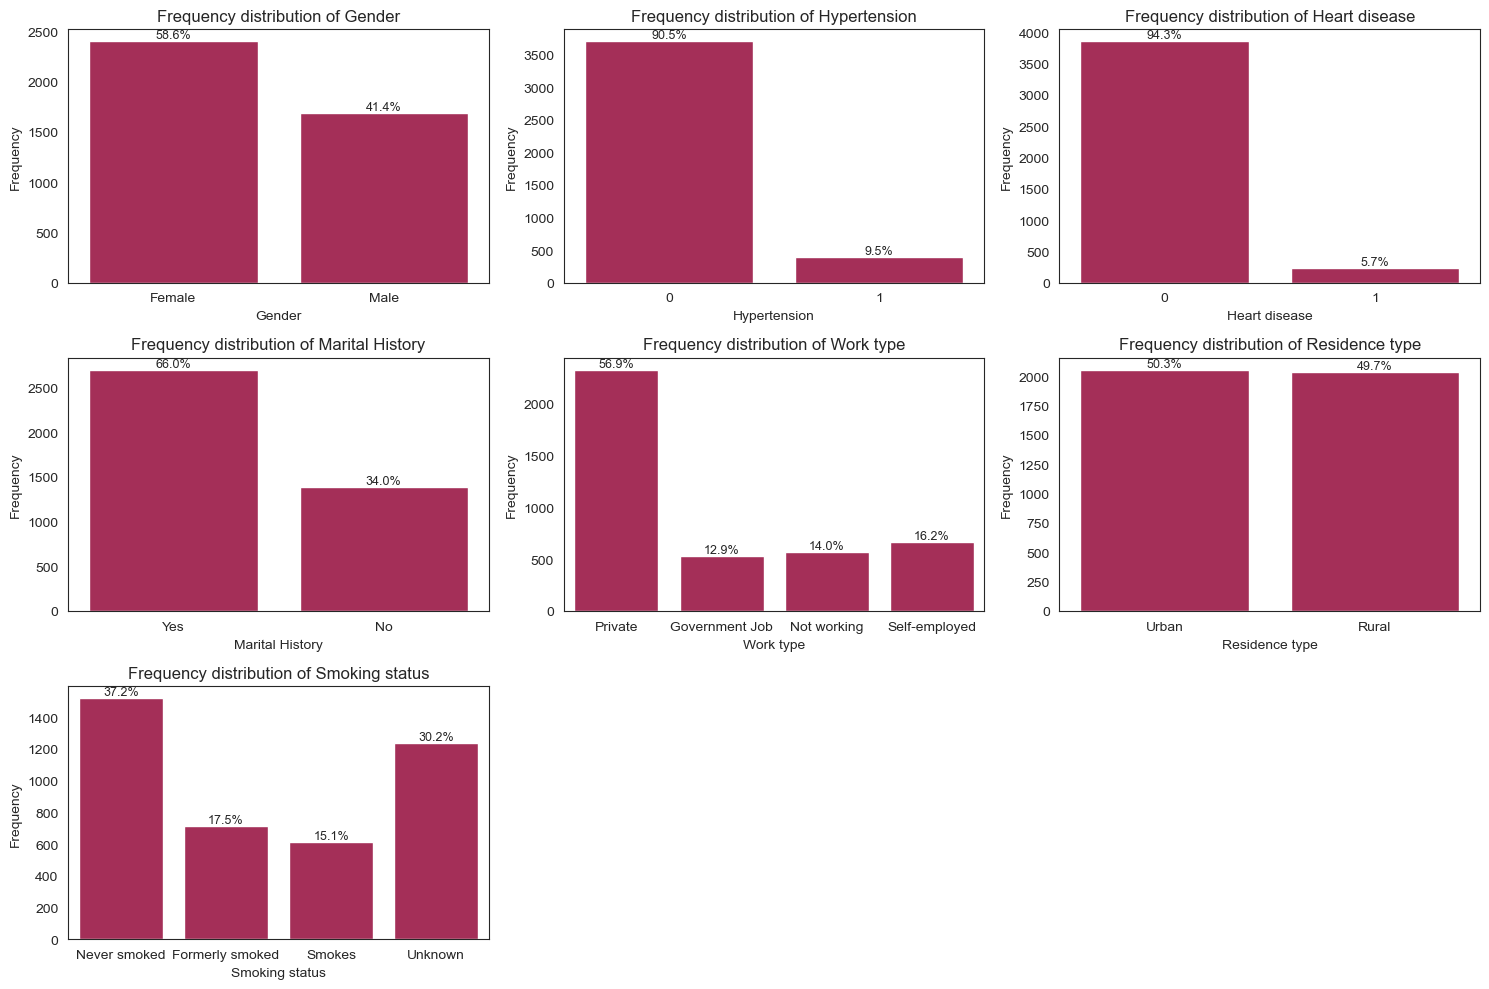

In [24]:
cols = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'residence_type', 'smoking_status']
titles = {'gender':'Gender', 'hypertension':'Hypertension', 'heart_disease':'Heart disease', 'ever_married':'Marital History', 
          'work_type':'Work type', 'residence_type':'Residence type', 'smoking_status':'Smoking status'}

fig, axes = plt.subplots(3, 3, figsize = (15, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    sns.countplot(data = train_df, x = col, ax = ax, color = "#B81B52")

    ax.set_xlabel(titles[col])
    ax.set_ylabel('Frequency')
    ax.set_title(f'Frequency distribution of {titles[col]}')

    # Annotating bars with percentage values
    total = sum(p.get_height() for p in ax.patches)

    for p in ax.patches:
        percentage = 100 * p.get_height()/total
        ax.annotate(
            f'{percentage:.1f}%',
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha = 'center',
            va = 'bottom',
            fontsize = 9
        )

fig.delaxes(axes[7])
fig.delaxes(axes[8])

plt.tight_layout()
plt.show()

### Stroke prevalence by demographics

**Age**  
Age demonstrates a strong relationship with stroke occurrence. While the non-stroke population shows a fairly normal distribution peaking around ages 50-55, stroke cases are heavily concentrated in older age groups, with minimal occurrence before age 40. Stroke frequency increases dramatically after age 50 and peaks around 75-80 years, suggesting age is a critical risk factor and likely to be highly predictive in our model.

**Gender**  
Males show slightly higher stroke prevalence (5.1%) compared to females (4.7%). This difference is relatively small, indicating gender alone may not be a strong predictor of stroke risk.

**Marital Status**  
Ever-married individuals show significantly higher stroke prevalence (6.5%) compared to those never married (1.7%). This represents nearly a 4x difference in stroke risk. This pattern likely reflects age confounding, as married individuals tend to be older, and age is strongly associated with stroke risk.

**Work Type**  
Self-employed individuals exhibit the highest stroke prevalence at 8.3%, while those not working show the lowest prevalence (0.2%), which is likely explained by this category including young people (children/students) who have minimal stroke risk. The elevated risk in self-employed individuals may reflect either older age demographics or higher stress/lifestyle factors.

**Residence Type**  
Urban residents show marginally higher stroke prevalence (5.3%) compared to rural residents (4.5%). This small difference suggests residence type may not be a major independent risk factor, though it could reflect differences in healthcare access, lifestyle, or detection rates between urban and rural areas.

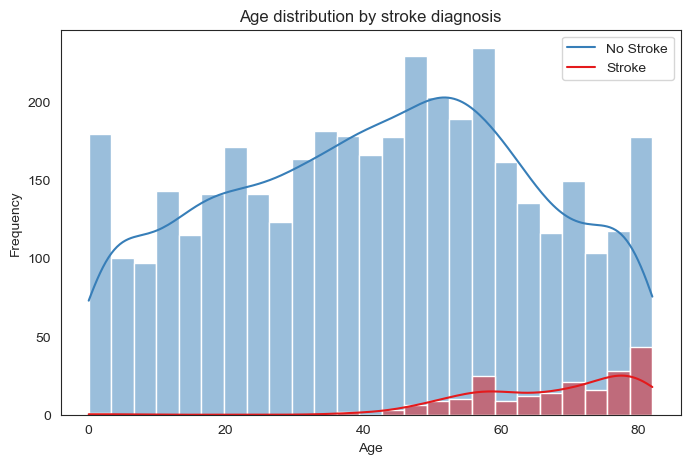

In [25]:
# Age distribution by stroke diagnosis
plt.figure(figsize=(8,5))

ax = sns.histplot(data = train_df, x = 'age', bins = 25, kde = True, hue = 'stroke', hue_order= [1,0], alpha = 0.5, palette='Set1')

ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
ax.set_title('Age distribution by stroke diagnosis')
ax.legend(labels = ['No Stroke', 'Stroke'])
plt.show()

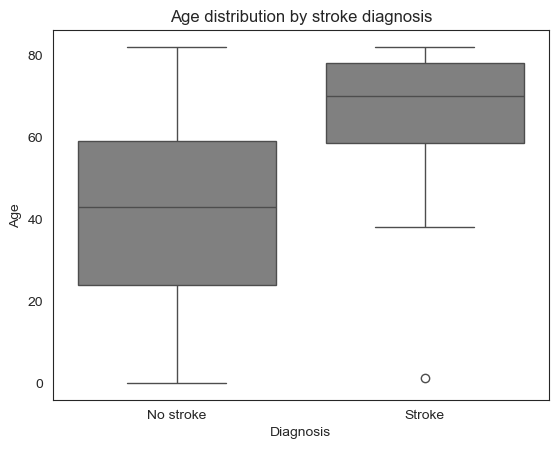

In [26]:
sns.boxplot(data = train_df, x = 'stroke', y = 'age', color ='grey')

plt.ylabel('Age')
plt.xlabel('Diagnosis')
plt.title('Age distribution by stroke diagnosis')
plt.xticks(ticks = [0,1], labels=['No stroke', 'Stroke'])
plt.show()

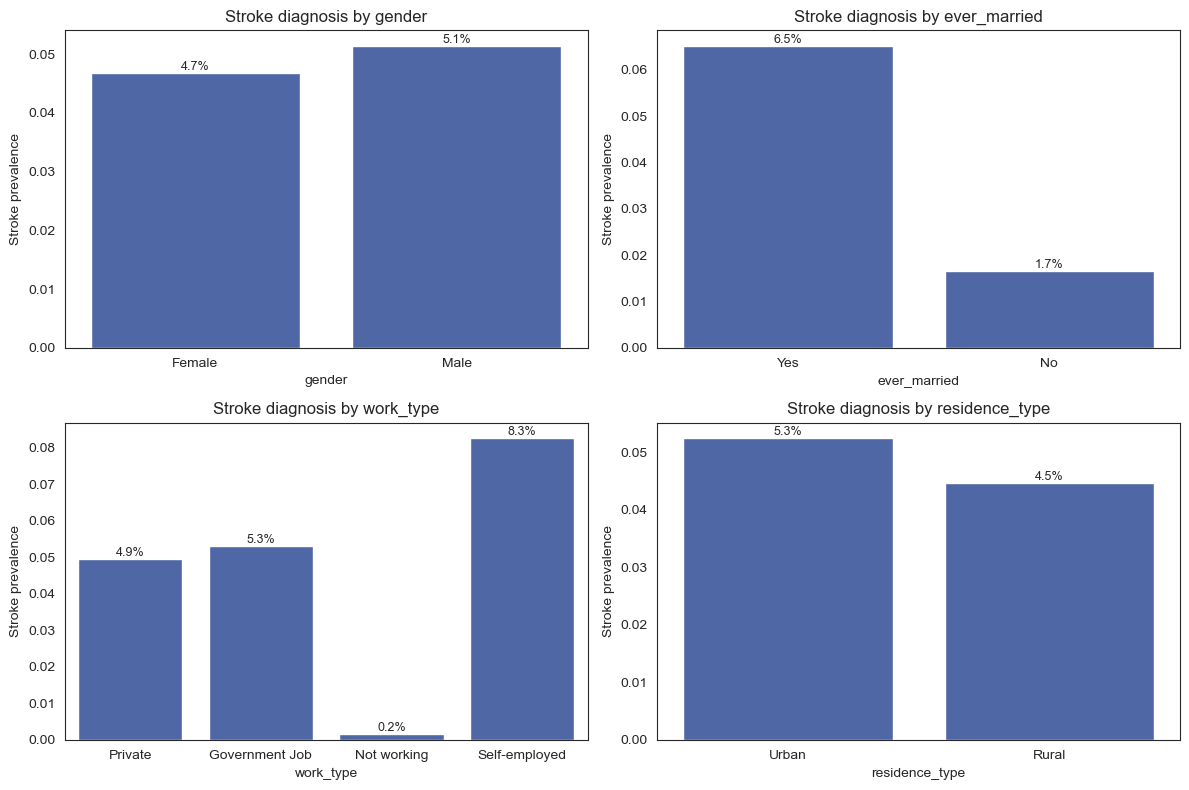

In [27]:
vars = ['gender', 'ever_married', 'work_type', 'residence_type']

fig, axes = plt.subplots(2,2, figsize = (12,8))
axes = axes.flatten()

for ax, var in zip(axes, vars):
    sns.barplot(data = train_df, x = var, y = 'stroke', estimator = 'mean', errorbar = None, ax = ax, color = '#4161B3')

    ax.set_title(f'Stroke diagnosis by {var}')
    ax.set_xlabel(var)
    ax.set_ylabel('Stroke prevalence')

    for p in ax.patches:
        prevalence = p.get_height() * 100
        ax.annotate(
            f'{prevalence:.1f}%',
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha = 'center',
            va = 'bottom',
            fontsize = 9
        )

plt.tight_layout()
plt.show()

### Stroke prevalence by clinical history


**Hypertension**  
Hypertensive individuals show 14.0% stroke prevalence vs. 3.9% in non-hypertensive individuals - a 3.6x increase, making this one of the strongest predictors in the dataset.

**Heart Disease**  
Heart disease shows the highest risk ratio: 15.5% vs. 4.2% (no heart disease) - a 3.7x increase. This is the strongest categorical predictor observed.

**Smoking Status**  
Former smokers showing highest risk of having a stroke, which likely reflects age confounding or individuals who quit due to health concerns.

**BMI Missing Data - Critical Issue**  
Records with missing BMI show 22.7% stroke prevalence vs. 4.1% with BMI recorded - a 5.5x difference. This strongly suggests that BMI is not missing at random (MNAR) and may reflect systematic missingness among older or clinically sicker individuals.

**Average Glucose Level**
Stroke patients have higher median glucose (~105 mg/dL) than non-stroke individuals (~85 mg/dL), with greater variability, more high-value outliers (>250 mg/dL), and a right-skewed distribution. This suggests elevated glucose may be associated with increased stroke risk.

**BMI**
Median BMI is slightly lower in stroke patients (~30) compared to non-stroke (~32), with similar distributions, spread, and overlapping interquartile ranges. BMI alone appears to be a weak predictor, likely confounded by the 22.7% missing BMI in stroke cases.

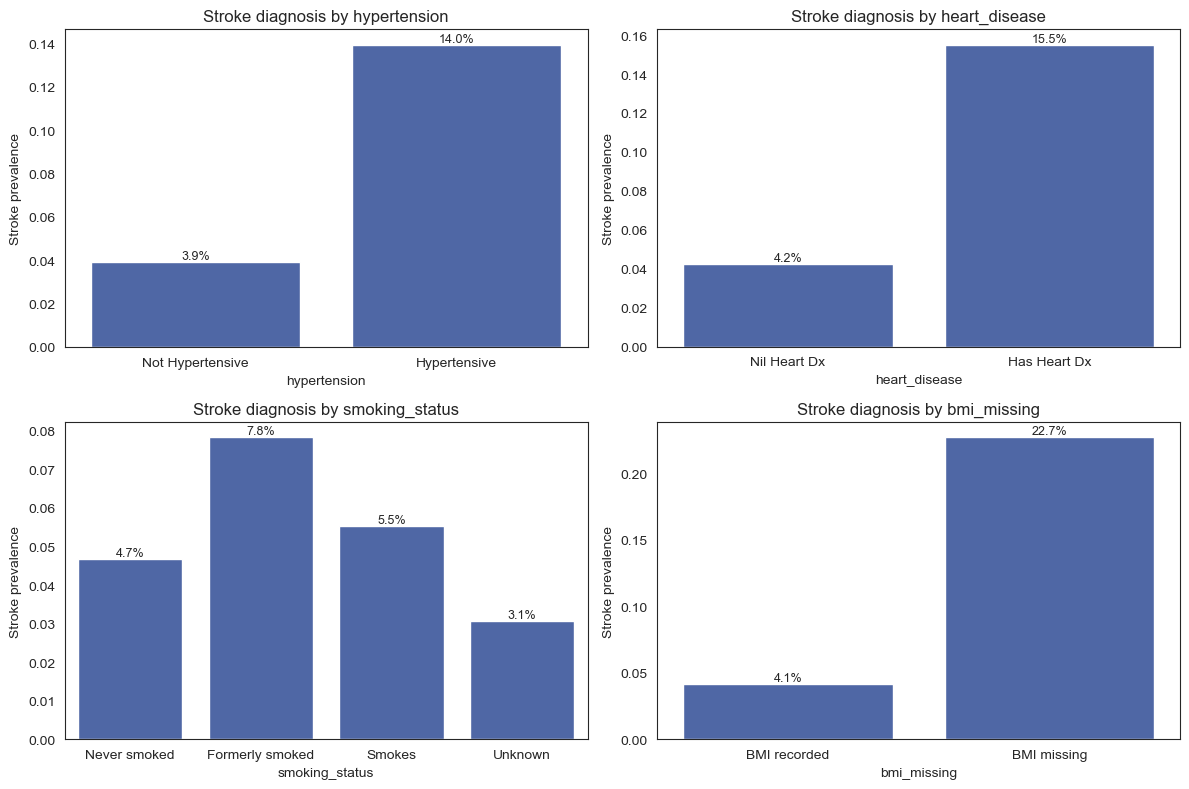

In [28]:
clin_vars = ['hypertension', 'heart_disease', 'smoking_status', 'bmi_missing']
label_maps = {
    'hypertension':{0:'Not Hypertensive', 1 : 'Hypertensive'},
    'heart_disease' : {0 : 'Nil Heart Dx', 1 : 'Has Heart Dx'},
    'bmi_missing': {0 : 'BMI recorded', 1 : 'BMI missing'}
}

fig, axes = plt.subplots(2,2, figsize = (12,8))
axes = axes.flatten()

for ax, var in zip(axes, clin_vars):
    sns.barplot(data = train_df, x = var, y = 'stroke', estimator = 'mean', errorbar = None, ax = ax, color = "#4161B3")

    ax.set_title(f'Stroke diagnosis by {var}')
    ax.set_xlabel(var)
    ax.set_ylabel('Stroke prevalence')

    if var in label_maps:
        ax.set_xticks([0,1])
        ax.set_xticklabels(label_maps[var].values())

    for p in ax.patches:
        prevalence = p.get_height() * 100
        ax.annotate(
            f'{prevalence:.1f}%',
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha = 'center',
            va = 'bottom',
            fontsize = 9
        )

plt.tight_layout()
plt.show()

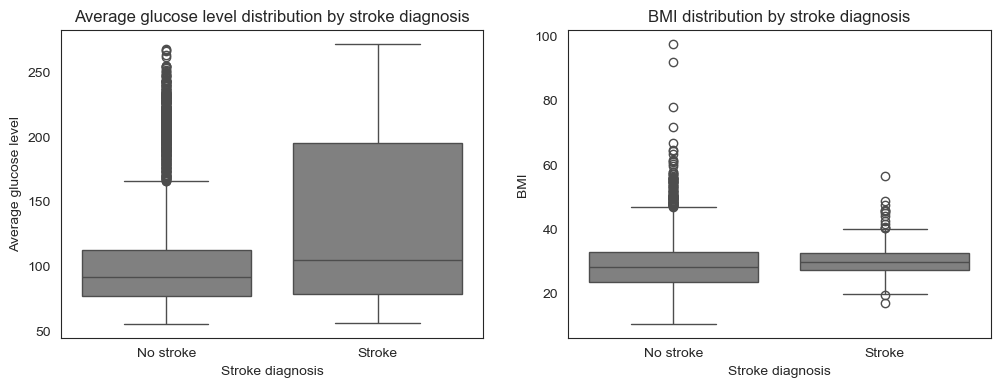

In [29]:
vars = ['avg_glucose_level', 'bmi']
title_labels = {
    'avg_glucose_level':'Average glucose level',
    'bmi':'BMI'
}


fig, axes = plt.subplots(1,2, figsize = (12, 4))
axes = axes.flatten()

for ax, var in zip(axes, vars):

    sns.boxplot(data = train_df, x = 'stroke', y = var, color = 'grey', ax = ax)

    ax.set_ylabel(title_labels[var])
    ax.set_xlabel('Stroke diagnosis')
    ax.set_title(f'{title_labels[var]} distribution by stroke diagnosis')
    ax.set_xticks([0,1])
    ax.set_xticklabels(['No stroke', 'Stroke'])

plt.show()

### Bivarate relationships
**Stroke Risk: Age * BMI**  
Stroke cases are concentrated in older age groups (60+) regardless of BMI, indicating that age is the primary risk factor, while BMI shows no clear pattern and appears weakly predictive.

**Stroke Risk: Age * Average Glucose Level**  
Stroke cases occur more frequently at higher glucose levels (150–270 mg/dL), particularly among older individuals, suggesting that elevated glucose combined with advanced age contributes to higher stroke risk.

**Stroke Risk: Age * Hypertension**  
Hypertension amplifies stroke risk across all age groups, with older hypertensive individuals (76+) showing the highest prevalence at 26.7%, and even younger hypertensives (31–45) having elevated risk compared to non-hypertensives.

**Stroke Risk: Age * Heart Disease**  
Hypertension amplifies stroke risk across all age groups, with older hypertensive individuals (76+) showing the highest prevalence at 26.7%, and even younger hypertensives (31–45) having elevated risk compared to non-hypertensives.

**Stroke Risk: Age × Gender**  
Gender differences are minimal in younger age groups, while older males (76+) have slightly higher risk than females. Age continues to dominate stroke prediction.

**Stroke Risk: Age × Smoking Status**  
Former smokers show elevated risk in middle age, but differences between smoking categories diminish in the oldest groups, as age overwhelms the signal.

**Stroke Risk: BMI × Average Glucose Level**  
BMI and glucose are largely uncorrelated, with stroke cases slightly concentrated at higher glucose levels, confirming glucose as a more predictive factor than BMI.

**Stroke Risk: Gender × Hypertension / Heart Disease / Smoking Status**  
Hypertension affects females more strongly than males (14.5% vs 11.9%), heart disease increases risk similarly across genders, and smoking history has a greater effect in males, particularly former smokers.

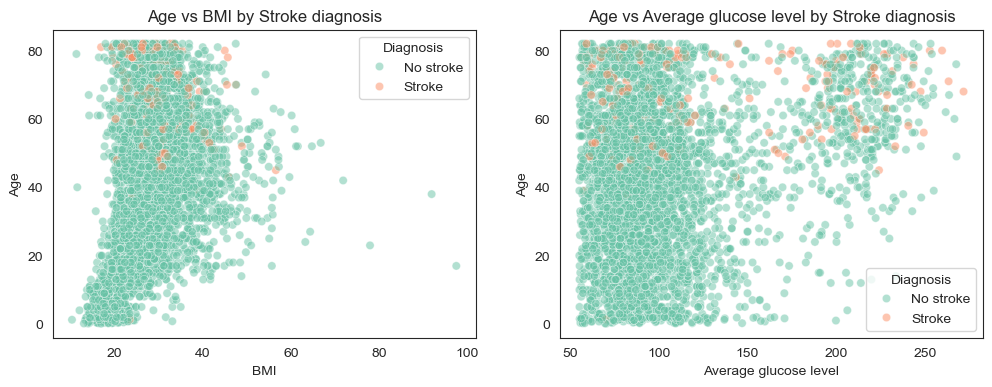

In [30]:
vars = ['bmi', 'avg_glucose_level']
title_labels = {
    'avg_glucose_level':'Average glucose level',
    'bmi':'BMI'
}

fig, axes = plt.subplots(1,2, figsize = (12, 4))
axes = axes.flatten()

for ax, x in zip(axes, vars):
    sns.scatterplot(data = train_df, 
                    x = x, y = 'age',
                    hue = 'stroke', palette= 'Set2', alpha = 0.5, ax = ax)


    ax.set_xlabel(title_labels[x])
    ax.set_ylabel('Age')
    ax.set_title(f'Age vs {title_labels[x]} by Stroke diagnosis')
    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        handles = handles,
        labels = ['No stroke', 'Stroke'],
        title = 'Diagnosis'
    )

plt.show()

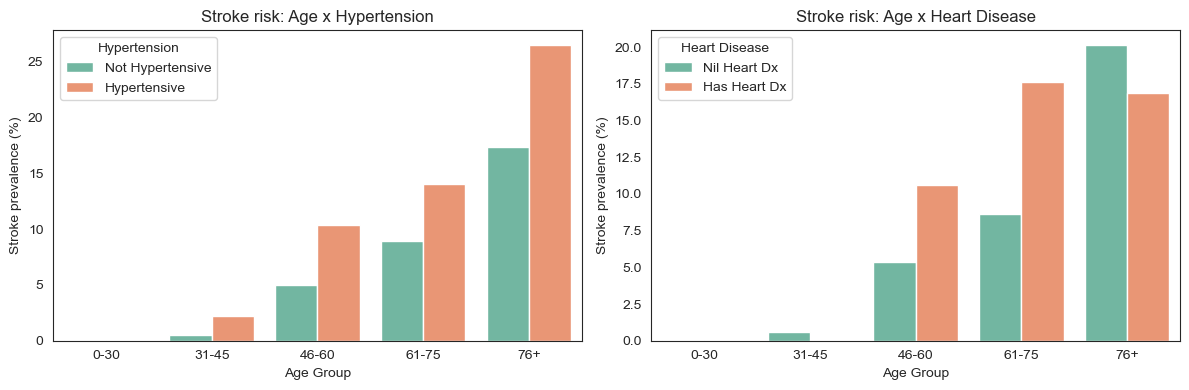

In [31]:
vars = ['hypertension', 'heart_disease']
title_labels = {'hypertension':'Hypertension', 'heart_disease':'Heart Disease'}

fig, axes = plt.subplots(1,2, figsize = (12, 4))
axes = axes.flatten()

for ax, hue in zip(axes, vars):
    sns.barplot(data = train_df,
                x = 'age_group', y = 'stroke', estimator = lambda x: x.mean() * 100,
                hue = hue, palette = 'Set2',
                errorbar = None, ax = ax)
    
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Stroke prevalence (%)')
    ax.set_title(f'Stroke risk: Age x {title_labels[hue]}')
    ax.legend(title = title_labels[hue], labels = label_maps[hue].values())

plt.tight_layout()
plt.show()  
    

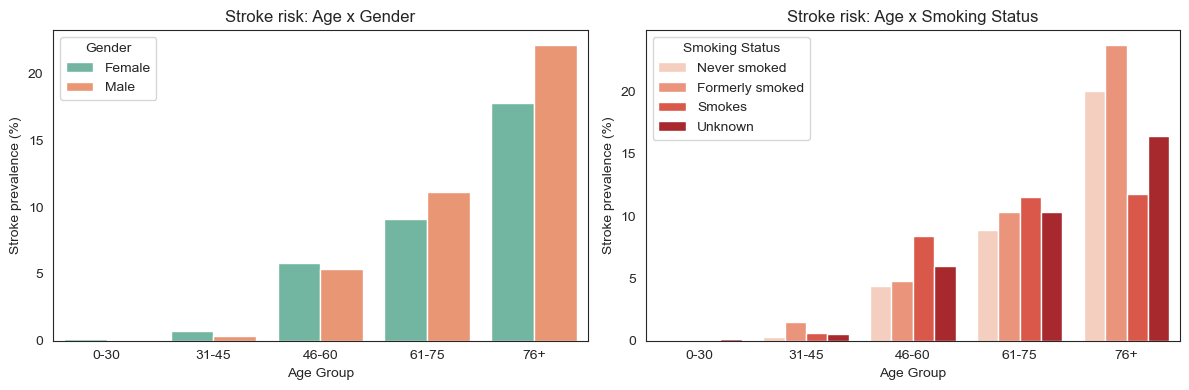

In [32]:
vars = ['gender', 'smoking_status']
title_labels = {'gender':'Gender', 'smoking_status':'Smoking Status'}
palette = {'gender':'Set2',
           'smoking_status':'Reds'}

fig, axes = plt.subplots(1,2, figsize = (12, 4))
axes = axes.flatten()

for ax, hue in zip(axes, vars):
    sns.barplot(data = train_df,
                x = 'age_group', y = 'stroke', estimator = (lambda x: x.mean() * 100),
                hue = hue, palette = palette[hue],
                errorbar = None, ax = ax)
    
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Stroke prevalence (%)')
    ax.set_title(f'Stroke risk: Age x {title_labels[hue]}')
    ax.legend(title = title_labels[hue])

plt.tight_layout()
plt.show()  

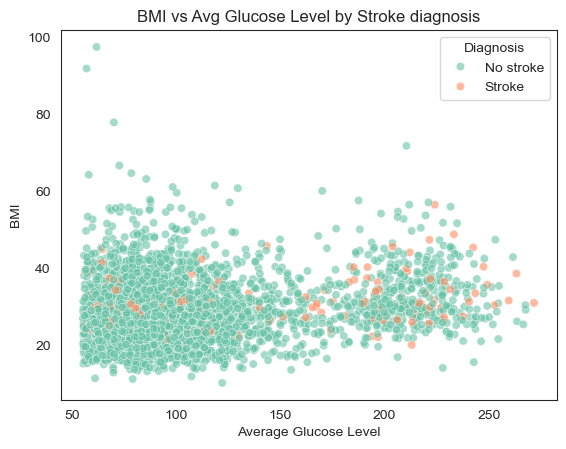

In [33]:
ax = sns.scatterplot(data = train_df,
                     x = 'avg_glucose_level', y = 'bmi',
                     hue = 'stroke', palette= 'Set2', alpha = 0.6)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
handles = handles,
labels= ['No stroke', 'Stroke'],
title = 'Diagnosis'
)

plt.xlabel('Average Glucose Level')
plt.ylabel('BMI')
plt.title('BMI vs Avg Glucose Level by Stroke diagnosis')

plt.show()

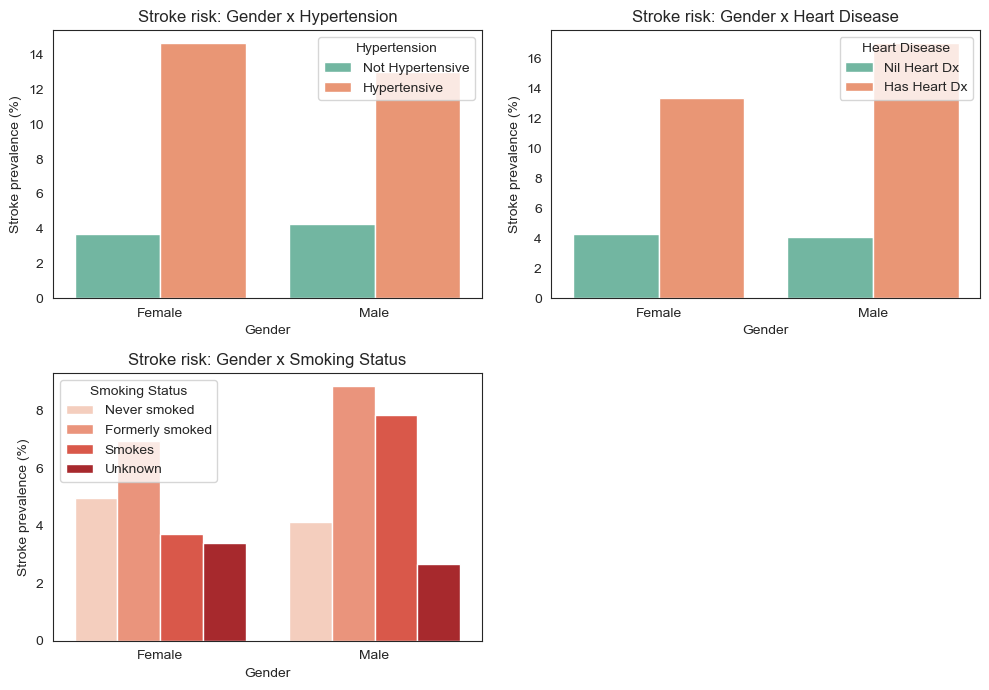

In [34]:
vars = ['hypertension', 'heart_disease','smoking_status']
title_labels = {'hypertension':'Hypertension', 'heart_disease':'Heart Disease', 'smoking_status':'Smoking Status'}
palette = {'hypertension':'Set2',
           'heart_disease':'Set2',
           'smoking_status':'Reds'}

fig, axes = plt.subplots(2,2, figsize = (10, 7))
axes = axes.flatten()

for ax, hue in zip(axes, vars):
    sns.barplot(data = train_df,
                x = 'gender', y = 'stroke', estimator = (lambda x: x.mean() * 100),
                hue = hue, palette = palette[hue],
                errorbar = None, ax = ax)
    
    ax.set_xlabel('Gender')
    ax.set_ylabel('Stroke prevalence (%)')
    ax.set_title(f'Stroke risk: Gender x {title_labels[hue]}')
    ax.legend(title = title_labels[hue], labels = list(label_maps[hue].values()) if hue in label_maps else None)

fig.delaxes(axes[3])    
plt.tight_layout()
plt.show()  

**Stroke Risk: Work Type x Residence Type**  
Self-employed individuals show the highest stroke risk in both urban (7.9%) and rural (8.8%) settings, with rural self-employed at greatest risk. Private and government workers have slightly higher risk in urban areas (~6% vs ~4.5%), while the "Not working" group maintains very low prevalence (<0.5%) across both residence types. Overall, work type is more predictive than residence type, though the self-employed × rural combination represents a notable higher-risk subgroup. Residence alone has minimal effect, with differences generally under 2%.

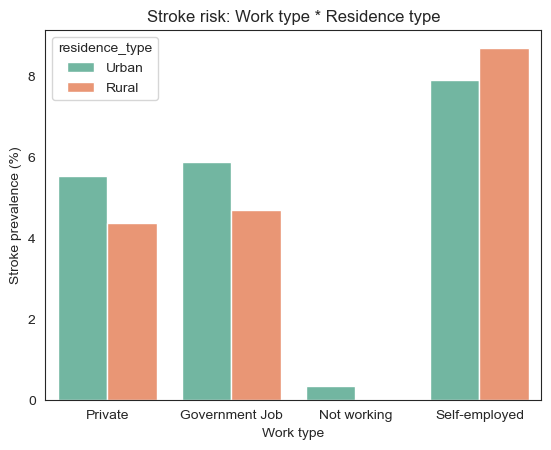

In [35]:
sns.barplot(data = train_df,
            x = 'work_type', y = 'stroke', hue = 'residence_type', palette='Set2',
            estimator= lambda x: x.mean() * 100, errorbar = None)

plt.xlabel('Work type')
plt.ylabel('Stroke prevalence (%)')
plt.title('Stroke risk: Work type * Residence type')
plt.show()

In [36]:
# Dropping helper age_group column
train_df = train_df.drop(columns = ['age_group'])
test_df = test_df.drop(columns = ['age_group'])

In [37]:
# Exporting training_df and test_df

train_df.to_parquet("train_df.parquet", index = False)
test_df.to_parquet("test_df.parquet", index = False)

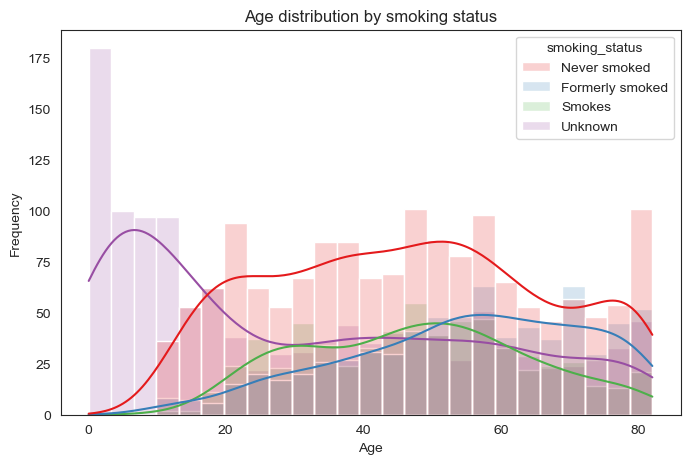

In [38]:
# Age distribution by smoking status
plt.figure(figsize=(8,5))

ax = sns.histplot(data = train_df, x = 'age', bins = 25, kde = True, hue = 'smoking_status', alpha = 0.2, palette='Set1')

ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
ax.set_title('Age distribution by smoking status')
plt.show()

In [39]:
train_df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_missing
845,25283,Female,48.0,0,0,Yes,Private,Urban,69.21,33.1,Never smoked,0,0
3745,41917,Female,29.0,0,0,No,Private,Urban,84.19,21.2,Never smoked,0,0
4184,36045,Female,35.0,0,0,Yes,Private,Rural,119.40,22.9,Never smoked,0,0
3410,28315,Male,38.0,0,0,Yes,Private,Rural,108.68,32.7,Never smoked,0,0
284,26325,Male,14.0,0,0,No,Government Job,Urban,82.34,31.6,Unknown,0,0


In [40]:
train_df['work_type'].value_counts()

work_type
Private           2324
Self-employed      664
Not working        571
Government Job     528
Name: count, dtype: int64

In [41]:
train_df['residence_type'].value_counts()

residence_type
Urban    2054
Rural    2033
Name: count, dtype: int64

In [44]:
train_df['hypertension'].value_counts()

hypertension
0    3700
1     387
Name: count, dtype: int64